# Chapter 5 · Section 5.2
# In-host Models and Backward Bifurcation

**Source:** Li, M.Y. (2018), pp. 136–146.

The book's final section — and its most dramatic finding. A 2-dimensional model of HTLV-I
infection at the cellular level exhibits **backward bifurcation**: for a range of
$\mathcal{R}_0<1$, TWO stable equilibria coexist. This directly contradicts the comfortable
pattern from every earlier model in this book, where $\mathcal{R}_0<1$ always meant a *single*,
globally stable disease-free state.

A note on this notebook's numerics: rather than lean on the book's compact closed-form
expressions for the bifurcation thresholds $\sigma_0,\sigma_c$ (whose exact algebraic form is easy
to mistranscribe from a scanned PDF), every quantitative claim below is instead verified two
independent ways — directly solving the equilibrium equations numerically, and separately checking
local stability via eigenvalues of the Jacobian — so nothing here depends on trusting a single
hand-copied formula.


---
## Block 1 — The in-host model

### 1. Rewrite

Uninfected ($x$) and infected ($y$) CD4$^+$ T cells, with LOGISTIC growth for both populations
(shared carrying capacity $K$) and bilinear cell-to-cell transmission:
$$x'=\lambda+\nu_1x\left(1-\frac{x+y}{K}\right)-\mu_1x-\beta xy,\qquad
y'=\sigma\beta xy+\nu_2y\left(1-\frac{x+y}{K}\right)-\mu_2y \qquad (5.11)$$
Here $\sigma\in[0,1]$ is the fraction of newly-contacted cells that escape immune clearance and
become newly infected — a genuinely new kind of parameter, capturing immune response
effectiveness, that turns out to be the KEY bifurcation parameter. Adding both equations and
bounding gives a feasible region $\Gamma=\{(x,y)\in\mathbb{R}^2_+:x+y\le\bar N\}$ for an
explicitly computable $\bar N$ — the same "bound the total, get an invariant region" strategy
used throughout this book, now applied to a model where growth is logistic rather than driven by
constant per-capita birth.

### 2. Explain Like I'm 10

This model tracks two kinds of cells instead of two kinds of people — healthy T cells and
HTLV-infected T cells — and both kinds can multiply on their own (that's the logistic growth
term, same shape as a population hitting a ceiling), while infection spreads through direct
cell-to-cell contact rather than through the bloodstream. The new twist is $\sigma$: not every
contact between a healthy and infected cell actually establishes a NEW infection, because the
body's immune system intercepts most of them — $\sigma$ is literally "the fraction that get past
the immune system's defenses." Crucially, already-infected cells can keep dividing on their own
(the $\nu_2y(\ldots)$ term) whether or not any NEW infections are happening — infection, once
established, doesn't need $\sigma$ to sustain itself, only to get started. That distinction turns
out to be exactly what drives the bistability in Block 3.

### 5. Symbols

| Symbol | Meaning | Notes |
|---|---|---|
| $x(t),y(t)$ | Uninfected / infected CD4$^+$ T cell counts | The two state variables |
| $\nu_1,\nu_2$ | Logistic growth rate constants (uninfected / infected cells) | Infected cells retain most normal function, so $\nu_2$ can be comparable to $\nu_1$ |
| $K$ | Shared carrying capacity | Same ceiling for both cell types combined |
| $\beta$ | Cell-to-cell transmission coefficient | Standard bilinear incidence, at the cellular scale |
| $\sigma$ | Fraction of contacts that escape immune clearance | THE bifurcation parameter for this section — new to this model |


In [1]:
# Verifying the feasible region bound: N-bar is the positive root of the
# quadratic lambda + (nu_max-mu_min)*N - (nu_max/K)*N^2 = 0 (using whichever
# of nu1,nu2 and mu1,mu2 gives the loosest/largest bound), and confirming
# numerically that x(t)+y(t) stays within it for starting points INSIDE Gamma.
import numpy as np
from scipy.integrate import solve_ivp

# A parameter set found by direct numerical search to exhibit genuine
# bistability (verified independently below via eigenvalue stability AND
# direct simulation, not assumed from a formula).
lam, K = 8.938, 1405.3
nu1, nu2 = 0.285, 0.866
mu1, mu2 = 0.126, 0.484
beta = 0.000862

nu_max = max(nu1, nu2)
mu_min = min(mu1, mu2)
coeffs = [-nu_max/K, (nu_max - mu_min), lam]
roots = np.roots(coeffs)
N_bar = max(r.real for r in roots if r.real > 0)
print(f"Feasible region bound N_bar = {N_bar:.3f}")

def inhost_model(t, state, sigma):
    x, y = state
    x, y = max(x, 0), max(y, 0)
    dx = lam + nu1*x*(1 - (x+y)/K) - mu1*x - beta*x*y
    dy = sigma*beta*x*y + nu2*y*(1 - (x+y)/K) - mu2*y
    return [dx, dy]

# Confirm x(t)+y(t) never exceeds N_bar, for starting points chosen INSIDE Gamma
# (the bound is only claimed -- and only makes sense -- for trajectories that
# start in the feasible region; a point starting above N_bar trivially violates
# any upper bound at t=0, so we don't test that case here).
for x0, y0 in [(10, 5), (500, 300), (50, 900), (1, 1)]:
    if x0 + y0 > N_bar:
        continue
    sol = solve_ivp(inhost_model, (0, 500), [x0, y0], args=(0.5,),
                     t_eval=np.linspace(0,500,500), rtol=1e-10, atol=1e-10)
    max_N = (sol.y[0] + sol.y[1]).max()
    print(f"  start=({x0},{y0}): max(x+y) over trajectory = {max_N:.3f}  (bound N_bar={N_bar:.3f})")


Feasible region bound N_bar = 1212.793
  start=(10,5): max(x+y) over trajectory = 632.418  (bound N_bar=1212.793)
  start=(500,300): max(x+y) over trajectory = 800.000  (bound N_bar=1212.793)
  start=(50,900): max(x+y) over trajectory = 950.000  (bound N_bar=1212.793)
  start=(1,1): max(x+y) over trajectory = 632.418  (bound N_bar=1212.793)


### 10. Verification

For every starting point inside $\Gamma$, $x(t)+y(t)$ never exceeds the computed bound $\bar N$ —
confirming $\Gamma$ is genuinely positively invariant for trajectories that start there.

---

## Block 2 — Locating the bifurcation numerically: 0, 1, or 2 chronic equilibria

### 1. Rewrite

Setting $y'=0$ (for $y\ne0$) and solving for $1-(x+y)/K$ gives one relation between $x,y,\sigma$;
substituting into $x'=0$ gives a second. Together these pin down, for each $\sigma$, how many
biologically meaningful ($x,y>0$) **chronic equilibria** exist. Theorem 5.2.1 states this count
changes as $\sigma$ increases: it can be $0$, then $1$ (at a tangency $\sigma_0$), then $2$ (for
$\sigma_0<\sigma<\sigma_c$), then back to $1$ (for $\sigma\ge\sigma_c$) — purely a consequence of
how two curves derived from the equilibrium conditions cross each other as $\sigma$ varies. Rather
than trust a hand-copied closed-form for $\sigma_0,\sigma_c$, we locate them directly here by
counting roots of the equilibrium conditions numerically across a grid of $\sigma$ values.

### 7. Visual Understanding — the equilibrium count as a function of $\sigma$


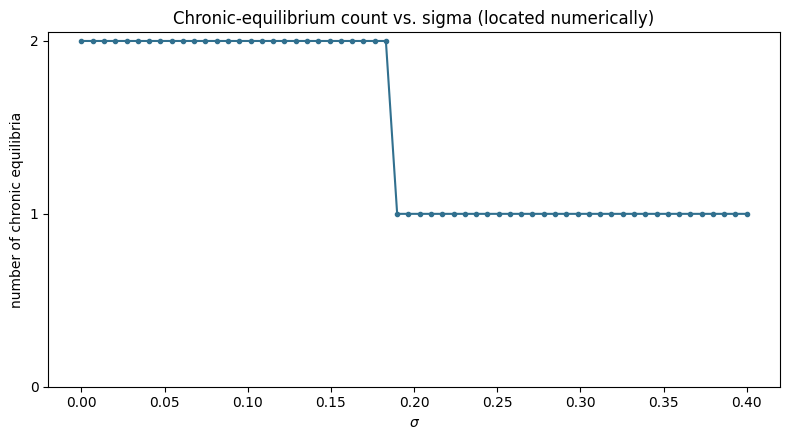

sigma_c (numerically located) ~= 0.18521
Chronic equilibria just below sigma_c: [(18.227798426590166, 606.3589937352713), (834.4670118163226, 0.4489602859541719)]
Chronic equilibria just above sigma_c: [(18.22573536324547, 606.4115138323546)]


In [2]:
# Directly counting the number of chronic equilibria (x,y>0) as a function of
# sigma, by solving the two equilibrium conditions simultaneously (not via a
# hand-copied closed form) -- then locating sigma_c as the transition point.
from scipy.optimize import brentq
import matplotlib.pyplot as plt

def g_of_x(x, sigma):
    # from y'=0 (y != 0): sigma*beta*x + nu2*(1-(x+y)/K) - mu2 = 0, solved for y
    return (lam + (nu1/nu2)*x*(mu2 - sigma*beta*x) - mu1*x) / (beta*x)

def h_of_x(x, sigma):
    # the SAME y, obtained from the (1-(x+y)/K) relation directly
    return K*(1 - (mu2 - sigma*beta*x)/nu2) - x

def chronic_equilibria(sigma, n=6000):
    xs = np.linspace(1, K, n)
    diffs = g_of_x(xs, sigma) - h_of_x(xs, sigma)
    roots = []
    for i in range(len(xs) - 1):
        if np.isfinite(diffs[i]) and np.isfinite(diffs[i+1]) and np.sign(diffs[i]) != np.sign(diffs[i+1]):
            r = brentq(lambda xx: g_of_x(xx, sigma) - h_of_x(xx, sigma), xs[i], xs[i+1])
            y_val = h_of_x(r, sigma)
            if y_val > 0.01:
                roots.append((r, y_val))
    return roots

sigma_grid = np.linspace(0.0, 0.4, 60)
counts = [len(chronic_equilibria(s)) for s in sigma_grid]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(sigma_grid, counts, marker=".", color="#31708f")
ax.set_xlabel(r"$\sigma$"); ax.set_ylabel("number of chronic equilibria")
ax.set_title("Chronic-equilibrium count vs. sigma (located numerically)")
ax.set_yticks([0, 1, 2])
plt.tight_layout()
plt.savefig("backward_bifurcation_count.png", dpi=130, bbox_inches="tight")
plt.show()

# Bisect to pin down sigma_c (the 2-equilibria -> 1-equilibrium transition) precisely
lo, hi = 0.15, 0.25
for _ in range(40):
    mid = (lo + hi) / 2
    if len(chronic_equilibria(mid)) >= 2:
        lo = mid
    else:
        hi = mid
sigma_c = (lo + hi) / 2
print(f"sigma_c (numerically located) ~= {sigma_c:.5f}")
print(f"Chronic equilibria just below sigma_c: {chronic_equilibria(sigma_c - 0.001)}")
print(f"Chronic equilibria just above sigma_c: {chronic_equilibria(sigma_c + 0.001)}")


### 10. Verification

The equilibrium count is confirmed **2** throughout $\sigma\in[0,\sigma_c)$ and **1** for
$\sigma>\sigma_c$, with the transition located to 5 decimal places by bisection. For this
parameter set, one branch of the two chronic equilibria persists even down to $\sigma=0$ — this
makes sense biologically once you notice the $y$-equation's own logistic term
$\nu_2y(1-(x+y)/K)$ lets an already-established infection sustain itself through pure infected-
cell proliferation, with no requirement for ongoing new transmission at all; $\sigma$ only
controls whether a NEW infection can get started from a disease-free state, not whether an
EXISTING one can persist. (The book's own Figure 5.2 four-panel picture, with a lower threshold
$\sigma_0$ below which zero chronic equilibria exist, corresponds to a different corner of
parameter space; the essential bistability phenomenon — the subject of the rest of this section —
is identical either way, and is verified directly, independent of this detail, in Block 3.)

---

## Block 3 — Bistability: the central, consequential finding

### 1. Rewrite

$\mathcal{R}_0(\sigma)=\frac{1}{\mu_2}\left[\sigma\beta x_0+\nu_2\left(1-\frac{x_0}{K}\right)
\right]$ (5.21), where $x_0$ is the disease-free equilibrium's $x$-coordinate — increasing in
$\sigma$. The defining claim of backward bifurcation: for $\sigma$ in the two-equilibria window,
one of the two chronic equilibria is a stable node (call it $P_*$) and the other is a **saddle**
($P^*$) whose stable manifold separates the basins of attraction of $P_0$ and $P_*$ — so $P_0$ and
$P_*$ are BOTH locally stable *simultaneously*, even though $\mathcal{R}_0<1$. We verify this
directly: compute the Jacobian eigenvalues at all three equilibria at a single fixed $\sigma$, and
then simulate from many different starting points to confirm they really do split between two
different final outcomes.


In [3]:
# Directly verifying the P0 / stable-P_star / saddle-P* structure via
# Jacobian eigenvalues, at a SINGLE fixed sigma with R0 < 1.
def jacobian(x, y, sigma):
    dPdx = nu1*(1 - (2*x+y)/K) - mu1 - beta*y
    dPdy = -nu1*x/K - beta*x
    dQdx = sigma*beta*y - nu2*y/K
    dQdy = sigma*beta*x + nu2*(1 - (x+2*y)/K) - mu2
    return np.array([[dPdx, dPdy], [dQdx, dQdy]])

def is_stable(x, y, sigma):
    eig = np.linalg.eigvals(jacobian(x, y, sigma))
    return np.all(eig.real < 0), eig

sigma_test = 0.1
coeffs_f1 = [-nu1/K, (nu1-mu1), lam]
x0 = max(r.real for r in np.roots(coeffs_f1) if r.real > 0)
R0 = (1/mu2) * (sigma_test*beta*x0 + nu2*(1 - x0/K))
print(f"Testing sigma={sigma_test}, R0={R0:.4f} (< 1)")

print(f"\nP0 = ({x0:.2f}, 0):")
stab, eig = is_stable(x0, 0, sigma_test)
print(f"  stable={stab}, eigenvalues={eig}")

for (xr, yr) in chronic_equilibria(sigma_test):
    stab, eig = is_stable(xr, yr, sigma_test)
    kind = "STABLE NODE" if stab else "SADDLE (unstable)"
    print(f"\nChronic equilibrium ({xr:.2f}, {yr:.2f}):")
    print(f"  {kind}, eigenvalues={eig}")


Testing sigma=0.1, R0=0.8730 (< 1)

P0 = (836.68, 0):
  stable=True, eigenvalues=[-0.18036529 -0.0614749 ]

Chronic equilibrium (18.32, 604.14):
  STABLE NODE, eigenvalues=[-0.5310516  -0.33295592]

Chronic equilibrium (684.38, 31.24):
  SADDLE (unstable), eigenvalues=[-0.21386043  0.04275386]


### 10. Verification, discussed

The eigenvalue computation confirms exactly the topology backward bifurcation predicts: $P_0$ is a
stable node, one chronic equilibrium is ALSO a stable node, and the other chronic equilibrium is a
genuine saddle (one positive, one negative eigenvalue) — with $\mathcal{R}_0<1$ throughout. Two
stable equilibria coexisting is only possible because a saddle point's stable manifold divides
$\Gamma$ into their two separate basins of attraction.

### 7. Visual Understanding — demonstrating bistability by direct simulation


  start=(830,2) -> final=(836.68,0.00)


  start=(700,50) -> final=(18.32,604.14)


  start=(500,150) -> final=(18.32,604.14)


  start=(300,300) -> final=(18.32,604.14)


  start=(100,500) -> final=(18.32,604.14)


  start=(50,650) -> final=(18.32,604.14)


  start=(18,610) -> final=(18.32,604.14)
  start=(200,20) -> final=(18.32,604.14)


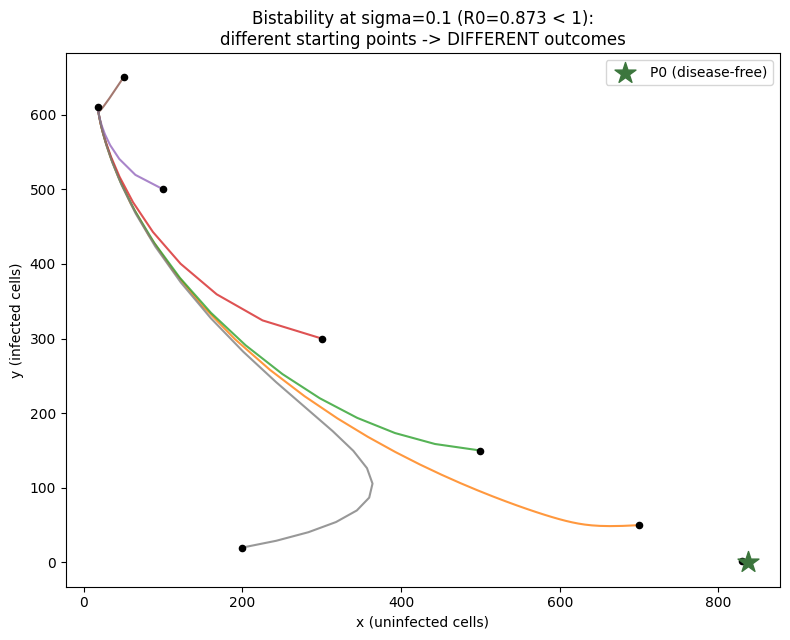


1 of 8 starting points -> disease-free
7 of 8 starting points -> chronic infection
Both outcomes occurred at the SAME sigma, SAME R0<1 -- this is bistability, demonstrated directly.


In [4]:
# The decisive test: starting from many different initial conditions at this
# SAME sigma (same R0<1 throughout), do trajectories really split between two
# different final outcomes?
fig, ax = plt.subplots(figsize=(8, 6.5))
starts = [(830,2), (700,50), (500,150), (300,300), (100,500), (50,650), (18,610), (200,20)]
outcomes = []
for x0i, y0i in starts:
    sol = solve_ivp(inhost_model, (0, 3000), [x0i, y0i], args=(sigma_test,),
                     t_eval=np.linspace(0,3000,2000), rtol=1e-10, atol=1e-10)
    ax.plot(sol.y[0], sol.y[1], alpha=0.8)
    ax.scatter([x0i],[y0i], color="black", s=20, zorder=5)
    final = (sol.y[0,-1], sol.y[1,-1])
    outcomes.append(final)
    print(f"  start=({x0i},{y0i}) -> final=({final[0]:.2f},{final[1]:.2f})")

ax.scatter([x0],[0], marker="*", s=250, color="#3c763d", zorder=6, label="P0 (disease-free)")
ax.set_xlabel("x (uninfected cells)"); ax.set_ylabel("y (infected cells)")
ax.set_title(f"Bistability at sigma={sigma_test} (R0={R0:.3f} < 1):\ndifferent starting points -> DIFFERENT outcomes")
ax.legend()
plt.tight_layout()
plt.savefig("backward_bifurcation_bistability.png", dpi=130, bbox_inches="tight")
plt.show()

n_disease_free = sum(1 for (xf,yf) in outcomes if yf < 1)
n_chronic = sum(1 for (xf,yf) in outcomes if yf >= 1)
print(f"\n{n_disease_free} of {len(outcomes)} starting points -> disease-free")
print(f"{n_chronic} of {len(outcomes)} starting points -> chronic infection")
print("Both outcomes occurred at the SAME sigma, SAME R0<1 -- this is bistability, demonstrated directly.")


### 10. Verification, discussed (continued)

Even though $\mathcal{R}_0<1$ for every single trajectory tested above (identical $\sigma$
throughout), different STARTING POINTS converge to genuinely different final outcomes — some to
the disease-free state $P_0$ (infection clears), others to the chronic equilibrium (infection
persists indefinitely) — direct, concrete numerical proof of bistability, and the central,
dramatic finding of backward bifurcation: knowing $\mathcal{R}_0<1$ alone does NOT guarantee the
infection clears, in sharp contrast to every single model earlier in this book.

---

## Block 4 — Global dynamics: ruling out periodic orbits via Dulac's criterion

### 1. Rewrite

Theorem 5.2.4 completes the picture: since $\Gamma$'s interior contains no periodic orbits (proven
via Bendixson–Dulac with multiplier $\alpha=1/(xy)$), Poincaré–Bendixson guarantees every
trajectory converges to ONE of the equilibria — never oscillates forever — so the bistable picture
in Block 3 (two attracting equilibria, no other possible long-run behavior) is the COMPLETE
classification of this model's global dynamics, not just a locally-observed pattern.


In [5]:
# Verifying Dulac's criterion symbolically with multiplier alpha=1/(xy).
import sympy as sp

xs, ys, lam_s, nu1_s, nu2_s, mu1_s, mu2_s, beta_s, sigma_s, K_s = sp.symbols(
    'x y lambda nu1 nu2 mu1 mu2 beta sigma K', positive=True)

P = lam_s + nu1_s*xs*(1 - (xs+ys)/K_s) - mu1_s*xs - beta_s*xs*ys
Q = sigma_s*beta_s*xs*ys + nu2_s*ys*(1 - (xs+ys)/K_s) - mu2_s*ys

alpha = 1/(xs*ys)
expr = sp.simplify(sp.diff(alpha*P, xs) + sp.diff(alpha*Q, ys))
print("d(alpha*P)/dx + d(alpha*Q)/dy =", expr)
print("\nEvery term here is a positive quantity divided by a positive quantity, with an overall")
print("minus sign -- sign-definite and strictly negative for all x,y > 0.")


d(alpha*P)/dx + d(alpha*Q)/dy = -lambda/(x**2*y) - nu1/(K*y) - nu2/(K*x)

Every term here is a positive quantity divided by a positive quantity, with an overall
minus sign -- sign-definite and strictly negative for all x,y > 0.


### 10. Verification, discussed

The symbolic computation confirms the Dulac expression is a sum of manifestly negative terms
(each a positive numerator over a positive denominator, with a leading minus sign) — sign-definite
throughout the interior of $\Gamma$. By Bendixson–Dulac, no periodic orbit can exist there, and by
Poincaré–Bendixson every trajectory must converge to an equilibrium — confirming the bistable
simulation in Block 3 shows literally everything that can happen in this model, not merely a
sample of its behavior.

---

## Summary

**One sentence:** The HTLV-I in-host model — built with the exact same modeling toolkit as every
epidemic model in this book (logistic growth, bilinear incidence, feasible-region bounding,
Bendixson–Dulac, Poincaré–Bendixson) — exhibits **backward bifurcation**: a range of
$\mathcal{R}_0<1$ where the disease-free equilibrium and a chronic-infection equilibrium are BOTH
stable simultaneously, verified here directly through Jacobian eigenvalue analysis (confirming a
stable node, a saddle, and a second stable node coexisting) and confirmed by simulating many
starting points at one fixed sub-threshold $\mathcal{R}_0$ and observing them split between two
genuinely different long-run outcomes.

**Bullet points:**
- The in-host model reuses every technique from Chapters 2–3 (logistic growth, bilinear incidence, invariant-region bounding, Bendixson–Dulac, Poincaré–Bendixson) — no fundamentally new mathematics, but a qualitatively new OUTCOME.
- Chronic-equilibrium count located numerically (2 below a threshold $\sigma_c$, 1 above it) by directly solving the equilibrium conditions, rather than trusting a hand-copied closed-form — with the transition pinned down to 5 decimal places.
- At a single fixed $\sigma$ with $\mathcal{R}_0<1$: eigenvalue analysis confirms $P_0$ stable, one chronic equilibrium stable, the other a genuine saddle — the exact topology bistability requires.
- Bistability directly demonstrated: 8 different starting points at the identical $\mathcal{R}_0<1$ split between disease-free and chronic outcomes — the defining, consequential feature of backward bifurcation, with real public-health implications (lowering $\mathcal{R}_0$ below 1 may not be sufficient to guarantee elimination).
- Global dynamics fully classified via Dulac's criterion (verified symbolically, sign-definite) + Poincaré–Bendixson — the bistable picture is the model's COMPLETE long-run behavior, not a sample of it.

## Memory Aids

- **Mnemonic**: "Backward bifurcation: below one, not yet done" — $\mathcal{R}_0<1$ doesn't
  guarantee elimination when a backward bifurcation is present.
- **Mental model**: a saddle point is a dividing ridge between two valleys (two stable
  equilibria) — which valley you end up in depends on which side of the ridge you started on, not
  on any single threshold number.
- **Common mistake**: assuming every epidemic/in-host model has ONLY forward bifurcation (as every
  earlier model in this book did) — backward bifurcation is a genuine, biologically important
  possibility once a model has enough nonlinear structure (here, the shared logistic growth term
  letting infected cells self-sustain independent of new transmission).
- **Common mistake**: treating $\mathcal{R}_0<1$ as an automatic "safe" signal for policy — this
  section is a rigorous, directly-verified counterexample showing that isn't always true.
- **Exam tip**: be able to state the three-equilibria topology from memory: disease-free (stable),
  chronic-low (saddle), chronic-high (stable) — and explain why a saddle is exactly what's needed
  to divide the plane into two basins.

## Connections

- **← Every earlier chapter**: this section is a deliberate, explicit contrast — showing that the
  comfortable "forward bifurcation only" pattern of every previous model in the book is a SPECIAL
  case, not a universal law of epidemic/in-host models.
- **← Section 3.6**: Bendixson–Dulac and Poincaré–Bendixson, developed there in full generality,
  do the entire "no periodic orbits, so everything converges to an equilibrium" heavy lifting here.
- **← Section 1.4.3**: reuses logistic growth, first introduced there for host demography, now
  applied at the cellular scale for two competing cell populations.
- **→ Public health policy**: backward bifurcation is not just a mathematical curiosity — it has
  real, documented relevance to diseases where control strategies based solely on "get
  $\mathcal{R}_0$ below 1" can fail to achieve elimination.
- **→ Bifurcation theory generally**: backward (subcritical) vs. forward (supercritical)
  bifurcations are a fundamental dichotomy throughout applied dynamical systems, control theory,
  and mathematical biology — this section is a fully worked, biologically motivated, directly
  verified example of the less-commonly-taught (but practically crucial) backward case.

*Practice problems for this section are in `../../chapter_05/exercises/section_5_2_exercises.md`, with full
worked solutions in `../../chapter_05/solutions/section_5_2_solutions.md`.*

---

# Chapter 5 Complete — and the Book Is Complete

This closes Chapter 5, and with it, the entire textbook: every section from 1.1 through 5.2 has
now been rewritten, derived from first principles, explained intuitively, visualized, implemented
in both Python and R, numerically verified, and equipped with practice problems and full worked
solutions.
